# Part 3 – Offshore Wind Park Electrical Design [10 pts]
OE44170 Offshore Renewable Technologies – Assignment: Electrical Aspects

Data read from the single-line diagram (SLD):
* WTGs of **12 MVA**; 12 strings, grouped in pairs → 6 groups of **11 WTGs = 132 MVA** each,
  every group connected to one 66 kV busbar section (one 66 kV transformer winding).
* **3 power transformers** 220/66/66 kV, 264/132/132 MVA (ONAN) and 400/200/200 MVA (ONAF).
* 66 kV and 220 kV busbars with bus-section couplers; **3 export cables** at 220 kV, one per transformer bay,
  each with a shunt reactor (… Mvar).

As in the assignment, power flows are expressed in MVA (apparent power) and losses/reactive power of the
collection system are neglected.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

FIG = Path("report/figures/electrical"); FIG.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200, "font.size": 10, "axes.grid": True, "grid.alpha": 0.3})

S_WTG = 12          # MVA
N_GROUPS = 6        # 66 kV bus sections / transformer windings
WTG_PER_GROUP = 11
N_TR = 3
S_TR_ONAN, S_TR_ONAF = 264, 400          # MVA (primary 220 kV)
S_W_ONAN, S_W_ONAF = 132, 200            # MVA per 66 kV winding
U_HV, U_MV = 220, 66                     # kV
N_EXPORT = 3

N_WTG = N_GROUPS * WTG_PER_GROUP
S_wind = N_WTG * S_WTG
print(f"{N_WTG} WTGs x {S_WTG} MVA = {S_wind} MVA installed wind power")
print(f"Transformer capacity ONAN: {N_TR} x {S_TR_ONAN} = {N_TR*S_TR_ONAN} MVA | ONAF: {N_TR} x {S_TR_ONAF} = {N_TR*S_TR_ONAF} MVA")

I = lambda S_MVA, U_kV: S_MVA * 1e3 / (np.sqrt(3) * U_kV)   # A

66 WTGs x 12 MVA = 792 MVA installed wind power
Transformer capacity ONAN: 3 x 264 = 792 MVA | ONAF: 3 x 400 = 1200 MVA


## Q1 – Power over one export cable (normal operation)

In [2]:
S_cable_normal = S_wind / N_EXPORT
print(f"S per export cable = {S_wind} MVA / {N_EXPORT} = {S_cable_normal:.0f} MVA "
      f"(= transformer ONAN rating {S_TR_ONAN} MVA)")

S per export cable = 792 MVA / 3 = 264 MVA (= transformer ONAN rating 264 MVA)


## Q2 – Currents in the transformer windings (normal operation)
$I = S / (\sqrt{3}\,U)$

In [3]:
S_winding = WTG_PER_GROUP * S_WTG
I_66 = I(S_winding, U_MV); I_220 = I(S_TR_ONAN, U_HV)
print(f"66 kV winding : {S_winding} MVA / (sqrt3 x 66 kV)  = {I_66:7.1f} A")
print(f"220 kV winding: {S_TR_ONAN} MVA / (sqrt3 x 220 kV) = {I_220:7.1f} A")
print(f"Check power balance: 2 x {S_winding} MVA = {2*S_winding} MVA in, {S_TR_ONAN} MVA out; "
      f"ratio of currents 2*I66/I220 = {2*I_66/I_220:.2f} = 220/66 = {220/66:.2f}")

66 kV winding : 132 MVA / (sqrt3 x 66 kV)  =  1154.7 A
220 kV winding: 264 MVA / (sqrt3 x 220 kV) =   692.8 A
Check power balance: 2 x 132 MVA = 264 MVA in, 264 MVA out; ratio of currents 2*I66/I220 = 3.33 = 220/66 = 3.33


## Q3 – Redundancy with one transformer out of service (N-1)
Definition used in the assignment: redundancy-ratio $= S_{wind,installed} / S_{transformers,available}$.

In [4]:
cases = []
def case(name, n_tr, rating):
    cap = n_tr * rating
    return {"case": name, "transformers in service": n_tr, "rating per TR [MVA]": rating,
            "available TR capacity [MVA]": cap, "installed wind [MVA]": S_wind,
            "wind / TR capacity [%]": 100 * S_wind / cap,
            "spare margin [MVA]": cap - S_wind}
cases.append(case("Normal, ONAN", 3, S_TR_ONAN))
cases.append(case("Normal, ONAF", 3, S_TR_ONAF))
cases.append(case("N-1, ONAN", 2, S_TR_ONAN))
cases.append(case("N-1, ONAF (emergency)", 2, S_TR_ONAF))
red = pd.DataFrame(cases).set_index("case").round(1)
display(red)

S_tr_N1 = S_wind / 2
print(f"N-1: each remaining transformer carries {S_wind}/2 = {S_tr_N1:.0f} MVA "
      f"-> {100*S_tr_N1/S_TR_ONAF:.0f} % of ONAF rating ({S_TR_ONAF} MVA)")
print(f"     each 66 kV winding carries {S_tr_N1/2:.0f} MVA = {I(S_tr_N1/2, 66):.0f} A "
      f"({100*(S_tr_N1/2)/S_W_ONAF:.0f} % of {S_W_ONAF} MVA ONAF)")
print(f"     220 kV winding current {I(S_tr_N1, 220):.0f} A")

,transformers in service,rating per TR [MVA],available TR capacity [MVA],installed wind [MVA],wind / TR capacity [%],spare margin [MVA]
case,,,,,,
"Normal, ONAN",3,264,792,792,100.0,0
"Normal, ONAF",3,400,1200,792,66.0,408
"N-1, ONAN",2,264,528,792,150.0,-264
"N-1, ONAF (emergency)",2,400,800,792,99.0,8


N-1: each remaining transformer carries 792/2 = 396 MVA -> 99 % of ONAF rating (400 MVA)
     each 66 kV winding carries 198 MVA = 1732 A (99 % of 200 MVA ONAF)
     220 kV winding current 1039 A


## Q4 – Optimal capacity of the export cable circuits
Because the 220 kV busbar sections can be coupled, the power of the two remaining transformers can be
spread over **all three** export cables during a transformer outage. The export-cable loading therefore does
not depend on the transformer N-1 case.

To support the choice, the park output duration is estimated from the template wind distribution and the
wake-affected park power curve (tab `WTG Yield Wake`, normalised to rated power) and scaled to 792 MVA.

/opt/anaconda3/lib/python3.13/site-packages/openpyxl/worksheet/_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


,cables in service,rating per cable [MVA],export capacity [MVA],capacity / wind [%],energy curtailed during this state [%],time park output > capacity [%]
0,3,264,792,100.0,0.0,0.0
1,2,264,528,66.7,17.3,38.3
2,3,400,1200,151.5,0.0,0.0
3,2,400,800,101.0,0.0,0.0
4,3,200,600,75.8,11.4,30.1


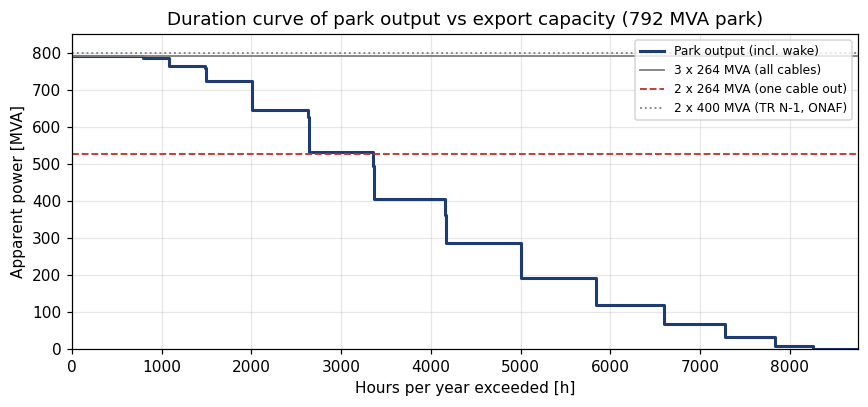

Capacity factor of park (approx.): 46.4%
Export cable at 264 MVA: current 693 A at 220 kV


In [5]:
raw = pd.read_excel("data/ORT_Assignment_Wind_Electrical.xlsx", sheet_name="WTG Yield Wake", header=None)
w = raw.iloc[13:42, [7, 3, 8, 10]].astype(float).fillna(0.0).reset_index(drop=True)
w.columns = ["v", "P", "pct", "eta"]; w.loc[w.v < 3, "eta"] = 0
w["p_pu"] = (w["P"] * w["eta"] / 20).clip(upper=1.0)        # park output in p.u. of installed capacity
w["S_park"] = w["p_pu"] * S_wind
E_tot = (w["S_park"] * w["pct"]).sum()

options = []
for n_cab, rating in [(3, 264), (2, 264), (3, 400), (2, 400), (3, 200)]:
    cap = n_cab * rating
    curtailed = (np.clip(w["S_park"] - cap, 0, None) * w["pct"]).sum() / E_tot
    options.append({"cables in service": n_cab, "rating per cable [MVA]": rating,
                    "export capacity [MVA]": cap, "capacity / wind [%]": 100*cap/S_wind,
                    "energy curtailed during this state [%]": 100*curtailed,
                    "time park output > capacity [%]": w.loc[w["S_park"] > cap + 1e-9, "pct"].sum()})
opt = pd.DataFrame(options).round(1)
display(opt)

# duration curve
order = np.argsort(-w["S_park"].values)
S_sorted = w["S_park"].values[order]; t_cum = np.cumsum(w["pct"].values[order]) / 100 * 8760
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.step(np.r_[0, t_cum], np.r_[S_sorted[0], S_sorted], where="pre", color="#1f3b73", lw=2, label="Park output (incl. wake)")
for cap, ls, lab in [(792, "-", "3 x 264 MVA (all cables)"), (528, "--", "2 x 264 MVA (one cable out)"),
                     (800, ":", "2 x 400 MVA (TR N-1, ONAF)")]:
    ax.axhline(cap, ls=ls, color="#c3312f" if cap == 528 else "grey", lw=1.2, label=lab)
ax.set_xlabel("Hours per year exceeded [h]"); ax.set_ylabel("Apparent power [MVA]")
ax.set_xlim(0, 8760); ax.set_ylim(0, 850); ax.legend(loc="upper right", fontsize=8)
ax.set_title("Duration curve of park output vs export capacity (792 MVA park)")
fig.tight_layout(); fig.savefig(FIG / "p3_duration_export_capacity.png"); plt.show()

print(f"Capacity factor of park (approx.): {(w['p_pu']*w['pct']).sum()/100:.1%}")
I_cable = I(S_cable_normal, U_HV)
print(f"Export cable at {S_cable_normal:.0f} MVA: current {I_cable:.0f} A at 220 kV")

## Q5 – Emergency cable to another offshore substation (OSS): quantitative context
Without the emergency cable, a loss of **all** export cables leaves the WTGs and OSS without auxiliary supply
(heating/dehumidification, yaw, lighting, navigation aids, SCADA). The emergency link avoids diesel
generators but cannot export power. A simple expected-value check is shown below with **illustrative**
assumptions (to be replaced by project data).

In [6]:
# illustrative assumptions
P_aux_per_WTG_kW = 30          # standby consumption per WTG (heating, dehumidification, control)
P_aux_OSS_kW = 300
n_days_blackout = 60           # duration of a full export outage (e.g. repair of a shared cable corridor)
diesel_cost_eur_per_MWh = 400  # incl. fuel logistics offshore
aux_MW = (N_WTG * P_aux_per_WTG_kW + P_aux_OSS_kW) / 1000
E_aux = aux_MW * 24 * n_days_blackout
print(f"Auxiliary load to keep the park energised: {aux_MW:.2f} MW")
print(f"Energy for a {n_days_blackout}-day outage: {E_aux:,.0f} MWh -> diesel cost ~ EUR {E_aux*diesel_cost_eur_per_MWh/1e6:.2f} M")
print(f"Required emergency cable capacity (energisation only, incl. inrush/charging margin): ~{3*aux_MW:.0f} MVA "
      f"-> a small 66 kV or 220 kV link, far below one export cable ({S_cable_normal:.0f} MVA)")

Auxiliary load to keep the park energised: 2.28 MW
Energy for a 60-day outage: 3,283 MWh -> diesel cost ~ EUR 1.31 M
Required emergency cable capacity (energisation only, incl. inrush/charging margin): ~7 MVA -> a small 66 kV or 220 kV link, far below one export cable (264 MVA)


In [7]:
pd.Series({
    "Installed wind [MVA]": S_wind,
    "Power per export cable, normal [MVA]": S_cable_normal,
    "Current 66 kV winding, normal [A]": round(I_66, 1),
    "Current 220 kV winding, normal [A]": round(I_220, 1),
    "N-1: load per transformer [MVA]": S_tr_N1,
    "N-1: wind / available TR capacity [%]": round(100*S_wind/(2*S_TR_ONAF), 1),
    "Export cable current at 264 MVA [A]": round(I_cable),
})

Installed wind [MVA]                      792.0
Power per export cable, normal [MVA]      264.0
Current 66 kV winding, normal [A]        1154.7
Current 220 kV winding, normal [A]        692.8
N-1: load per transformer [MVA]           396.0
N-1: wind / available TR capacity [%]      99.0
Export cable current at 264 MVA [A]       693.0
dtype: float64